# SVM Classification - sklearn in Action

> **MLCourse · Machine Learning · supervised · classification**

Widest-street classification on REAL data: sklearn's bundled **breast cancer**
set for the main workflow, plus a two-feature visual where you can SEE margins.

## What you'll learn
- SVC end-to-end in a scaled pipeline
- What C and gamma actually do (visual sweeps, not formulas)
- Support vectors: how few points define the boundary
- Grid-searching kernels honestly

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target            # 0=malignant, 1=benign

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

pipe = Pipeline([("sc", StandardScaler()),
                 ("svm", SVC(kernel="rbf", C=1.0))]).fit(X_tr, y_tr)
print(f"default RBF test accuracy: {accuracy_score(y_te, pipe.predict(X_te)):.4f}")
cv = cross_val_score(pipe, X_tr, y_tr, cv=5)
print(f"5-fold CV: {cv.mean():.4f} ± {cv.std():.4f}")

pd.DataFrame(confusion_matrix(y_te, pipe.predict(X_te)),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

default RBF test accuracy: 0.9790
5-fold CV: 0.9647 ± 0.0224


,pred malignant,pred benign
true malignant,52,1
true benign,2,88


## 1. The C knob - violation pricing

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


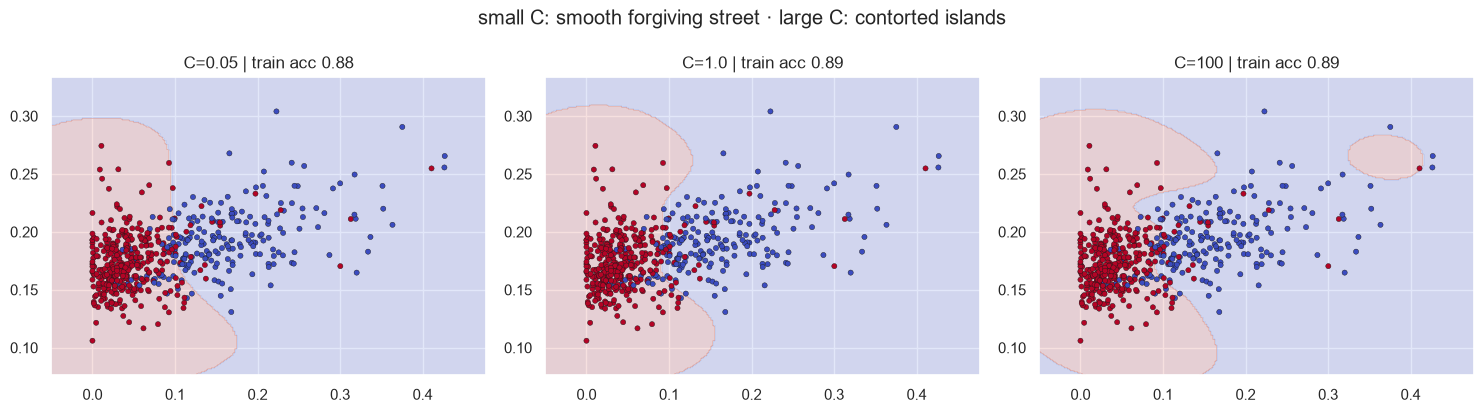

In [2]:
two = ["mean concavity", "mean symmetry"]
p2_base = Pipeline([("sc", StandardScaler()), ("svm", SVC())])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, c_val in zip(axes, [0.05, 1.0, 100]):
    m = p2_base.set_params(svm__C=c_val).fit(cancer.data[two], cancer.target)
    gx = np.linspace(*ax.get_xlim() if False else
                     (cancer.data[two[0]].min()-.05, cancer.data[two[0]].max()+.05), 220)
    gy = np.linspace(cancer.data[two[1]].min()-.03, cancer.data[two[1]].max()+.03, 220)
    Gxx, Gyy = np.meshgrid(gx, gy)
    zz = m.predict(np.c_[Gxx.ravel(), Gyy.ravel()]).reshape(Gxx.shape)
    ax.contourf(Gxx, Gyy, zz, alpha=.16, cmap="coolwarm")
    ax.scatter(cancer.data[two[0]], cancer.data[two[1]],
               c=cancer.target, cmap="coolwarm", s=14, edgecolor="k", lw=.3)
    acc = m.score(cancer.data[two], cancer.target)
    ax.set_title(f"C={c_val} | train acc {acc:.2f}")
plt.suptitle("small C: smooth forgiving street · large C: contorted islands")
plt.tight_layout(); plt.show()

## 2. The gamma knob - RBF bubble size

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


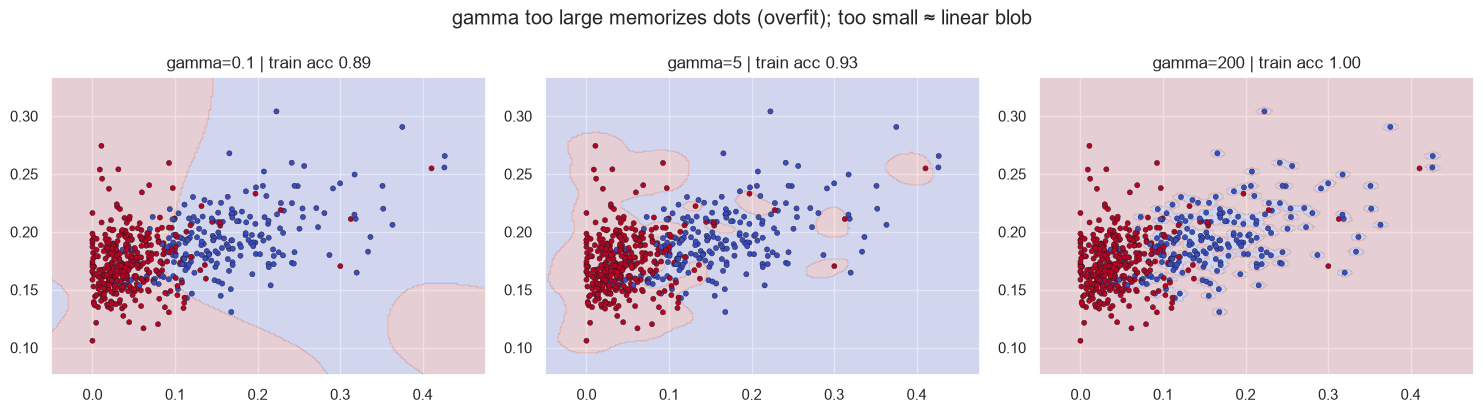

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, g in zip(axes, [0.1, 5, 200]):
    m = p2_base.set_params(svm__gamma=g).fit(cancer.data[two], cancer.target)
    zz = m.predict(np.c_[Gxx.ravel(), Gyy.ravel()]).reshape(Gxx.shape)
    ax.contourf(Gxx, Gyy, zz, alpha=.16, cmap="coolwarm")
    ax.scatter(cancer.data[two[0]], cancer.data[two[1]],
               c=cancer.target, cmap="coolwarm", s=14, edgecolor="k", lw=.3)
    ax.set_title(f"gamma={g} | train acc {m.score(cancer.data[two], cancer.target):.2f}")
plt.suptitle("gamma too large memorizes dots (overfit); too small ≈ linear blob")
plt.tight_layout(); plt.show()

## 3. Honest grid search on the full 30 features

In [4]:
grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("svm", SVC())]),
    {"svm__C": [0.1, 1, 10, 100],
     "svm__gamma": ["scale", 0.01, 0.1, 1],
     "svm__kernel": ["rbf", "linear"]},
    cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)

print("best:", grid.best_params_)
print(f"CV accuracy : {grid.best_score_:.4f}")
print(f"test accuracy: {grid.score(X_te, y_te):.4f}")

n_sv = grid.best_estimator_.named_steps["svm"].support_.shape[0]
print(f"\nsupport vectors used: {n_sv} of {len(X_tr)} rows "
      f"({n_sv/len(X_tr):.0%}) - the only points that define the boundary")

best: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
CV accuracy : 0.9718
test accuracy: 0.9720

support vectors used: 88 of 426 rows (21%) — the only points that define the boundary


## Summary & key takeaways

- SVM maximizes MARGIN width; only support vectors matter after training.
- C = cost of violations (small=humble), gamma = RBF curvature reach.
- Kernels bend the street without explicit feature engineering.
- Scaling is non-negotiable; grid-search C×gamma with CV before trusting it.